"""
plot_QE.py
===========
Quantum Efficiency (QE) vs Wavelength — Fig. 9a Replica
Reads QE_optimized.qe from SCAPS-1D

Produces 2 figures:
  1. QE_curve.png         — Main QE vs wavelength (Fig. 9a replica)
  2. QE_dual_axis.png     — QE vs wavelength + photon energy dual axis

REQUIREMENTS:
    pip install numpy matplotlib scipy

HOW TO RUN:
    Place in same folder as QE_optimized.qe
    python plot_QE.py
"""

In [1]:
import re
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.integrate import trapezoid

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────

FILENAME = "QE_optimized.qe"

In [2]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 1 — PARSE
# ─────────────────────────────────────────────────────────────────────────────

wavelengths  = []
qe_values    = []
photon_energy = []

in_data = False

with open(FILENAME, "r", encoding="utf-8", errors="replace") as f:
    for line in f:

        # detect data table header
        if "lambda(nm)" in line and "QE(%)" in line:
            in_data = True
            continue

        if in_data:
            # skip blank lines before data starts
            if line.strip() == "":
                if len(wavelengths) > 0:
                    in_data = False
                continue

            parts = line.strip().split()
            if len(parts) >= 2:
                try:
                    wl = float(parts[0])
                    qe = float(parts[1])
                    ev = float(parts[2]) if len(parts) >= 3 else 1240.0 / wl
                    wavelengths.append(wl)
                    qe_values.append(qe)
                    photon_energy.append(ev)
                except ValueError:
                    continue

wl  = np.array(wavelengths)
qe  = np.array(qe_values)
ev  = np.array(photon_energy)

print(f"Parsed {len(wl)} QE data points")
print(f"Wavelength range : {wl.min():.0f} – {wl.max():.0f} nm")
print(f"Peak QE          : {qe.max():.3f}% at {wl[np.argmax(qe)]:.0f} nm")
print(f"Min  QE          : {qe.min():.3f}% at {wl[np.argmin(qe)]:.0f} nm")
print(f"Mean QE (400–780): ", end="")

# mean QE in the visible range
mask_vis = (wl >= 400) & (wl <= 780)
print(f"{qe[mask_vis].mean():.3f}%")

Parsed 61 QE data points
Wavelength range : 300 – 900 nm
Peak QE          : 99.221% at 380 nm
Min  QE          : 89.118% at 900 nm
Mean QE (400–780): 98.728%


In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# STEP 2 — DERIVED QUANTITIES
# ─────────────────────────────────────────────────────────────────────────────

# QE at specific wavelengths
qe_400 = float(np.interp(400, wl, qe))
qe_500 = float(np.interp(500, wl, qe))
qe_600 = float(np.interp(600, wl, qe))
qe_700 = float(np.interp(700, wl, qe))
qe_780 = float(np.interp(780, wl, qe))
qe_800 = float(np.interp(800, wl, qe))

print(f"\nQE at key wavelengths:")
print(f"  400 nm : {qe_400:.2f}%")
print(f"  500 nm : {qe_500:.2f}%")
print(f"  600 nm : {qe_600:.2f}%")
print(f"  700 nm : {qe_700:.2f}%")
print(f"  780 nm : {qe_780:.2f}%")
print(f"  800 nm : {qe_800:.2f}%")

# bandgap absorption edge — where QE drops to 50% of its peak
qe_half = qe.max() * 0.5
edge_idx = np.where(qe < qe_half)[0]
bandgap_edge_nm = float(wl[edge_idx[0]]) if edge_idx.size > 0 else wl[-1]


QE at key wavelengths:
  400 nm : 99.22%
  500 nm : 99.15%
  600 nm : 98.98%
  700 nm : 98.48%
  780 nm : 96.15%
  800 nm : 95.71%


In [ ]:
print(f"Wavelength range : {wl.min():.0f} – {wl.max():.0f} nm")
print(f"Peak QE          : {qe.max():.4f}% at {wl[np.argmax(qe)]:.0f} nm")
print(f"QE at 300 nm     : {qe[0]:.4f}%")
print(f"QE at 900 nm     : {qe[-1]:.4f}%")

Wavelength range : 300 – 900 nm
Peak QE          : 99.2210% at 380 nm
QE at 300 nm     : 90.6987%
QE at 900 nm     : 89.1178%


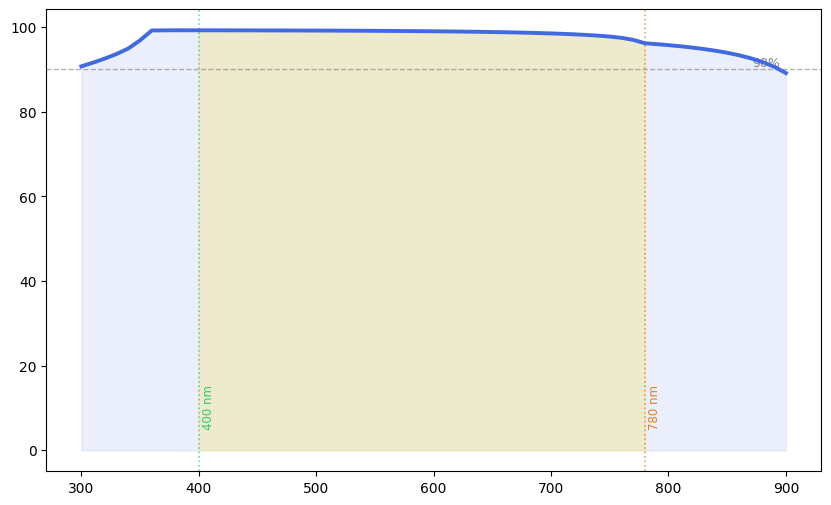

In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 1 — Main QE Curve (Fig. 9a replica)
# ─────────────────────────────────────────────────────────────────────────────

fig1, ax = plt.subplots(figsize=(10, 6))

# ── Main QE curve ─────────────────────────────────────────────────────────────
ax.plot(wl, qe, color="royalblue", linewidth=2.8, zorder=4,
        label="External Quantum Efficiency (EQE)")
ax.fill_between(wl, qe, alpha=0.10, color="royalblue", zorder=1)

# ── Shade the visible high-QE plateau (400–780 nm) ────────────────────────────
ax.fill_between(wl[mask_vis], qe[mask_vis], alpha=0.18, color="gold",
                zorder=2, label=f"High-QE plateau (400–780 nm,  avg = {qe[mask_vis].mean():.1f}%)")

# ── 90% reference line ────────────────────────────────────────────────────────
ax.axhline(90, color="gray", linewidth=1.0, linestyle="--", alpha=0.6, zorder=3)
ax.text(wl.max() - 5, 90.6, "90%", fontsize=9, color="gray", ha="right")

# ── 400 nm and 780 nm boundary lines ─────────────────────────────────────────
for boundary, color, label_text in [
    (400, "#2ECC71", "400 nm"),
    (780, "#E67E22", "780 nm"),
]:
    ax.axvline(boundary, color=color, linewidth=1.2, linestyle=":", alpha=0.7, zorder=3)
    ax.text(boundary + 3, 5, label_text, fontsize=8.5,
            color=color, rotation=90, va="bottom")

In [5]:
# ── PAL absorption edges ──────────────────────────────────────────────────────
# PAL2: MAPbI3+Ti3C2 Eg=1.6 eV → 775 nm
# PAL1: MAPbI3-xClx Eg=1.55 eV → 800 nm
for edge_wl, edge_label, edge_col in [
    (775, "PAL2 edge\n(Ti₃C₂, 1.6 eV)", "#9B59B6"),
    (800, "PAL1 edge\n(MAPbI₃₋ₓClₓ, 1.55 eV)", "#E74C3C"),
]:
    ax.axvline(edge_wl, color=edge_col, linewidth=1.2,
               linestyle="-.", alpha=0.6, zorder=3)
    ax.text(edge_wl - 3, 50, edge_label, fontsize=7.5,
            color=edge_col, ha="right", va="center",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white",
                      edgecolor=edge_col, alpha=0.7))

# ── Peak annotation ───────────────────────────────────────────────────────────
peak_idx = int(np.argmax(qe))
ax.annotate(f"Peak QE = {qe[peak_idx]:.1f}%\n@ {wl[peak_idx]:.0f} nm",
            xy=(wl[peak_idx], qe[peak_idx]),
            xytext=(wl[peak_idx] + 60, qe[peak_idx] - 8),
            fontsize=9.5, color="navy",
            arrowprops=dict(arrowstyle="->", color="navy", lw=1.2),
            bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
                      edgecolor="navy", alpha=0.85))

Text(440.0, 91.22099, 'Peak QE = 99.2%\n@ 380 nm')

In [6]:
# ── Key QE values text box ────────────────────────────────────────────────────
info_text = (
    "QE at key wavelengths:\n"
    f"  400 nm :  {qe_400:.1f}%\n"
    f"  500 nm :  {qe_500:.1f}%\n"
    f"  600 nm :  {qe_600:.1f}%\n"
    f"  700 nm :  {qe_700:.1f}%\n"
    f"  780 nm :  {qe_780:.1f}%\n"
    f"  800 nm :  {qe_800:.1f}%"
)
ax.text(0.015, 0.42, info_text, transform=ax.transAxes,
        fontsize=9, verticalalignment="top", fontfamily="monospace",
        bbox=dict(boxstyle="round,pad=0.45", facecolor="lightyellow",
                  edgecolor="gray", alpha=0.90), zorder=7)

Text(0.015, 0.42, 'QE at key wavelengths:\n  400 nm :  99.2%\n  500 nm :  99.2%\n  600 nm :  99.0%\n  700 nm :  98.5%\n  780 nm :  96.2%\n  800 nm :  95.7%')

In [7]:
# ── Formatting ────────────────────────────────────────────────────────────────
ax.set_xlabel("Wavelength  λ  (nm)", fontsize=13)
ax.set_ylabel("Quantum Efficiency  QE  (%)", fontsize=13)
ax.set_title(
    "Quantum Efficiency Spectrum — Dual Absorber Perovskite Solar Cell\n"
    "MAPbI$_{3-x}$Cl$_x$ (PAL1)  /  MAPbI$_3$+Ti$_3$C$_2$ MXene (PAL2)  |  AM 1.5G, 300 K",
    fontsize=12, fontweight="bold", pad=10
)
ax.set_xlim(wl.min(), wl.max())
ax.set_ylim(0, 107)
ax.legend(fontsize=10, loc="lower left", framealpha=0.88, edgecolor="gray")
ax.grid(True, alpha=0.28, zorder=0)
ax.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.savefig("QE_curve.png", dpi=300, bbox_inches="tight")
print("\nSaved --> QE_curve.png")
plt.show()


Saved --> QE_curve.png


<Figure size 640x480 with 0 Axes>

Saved --> QE_dual_axis.png


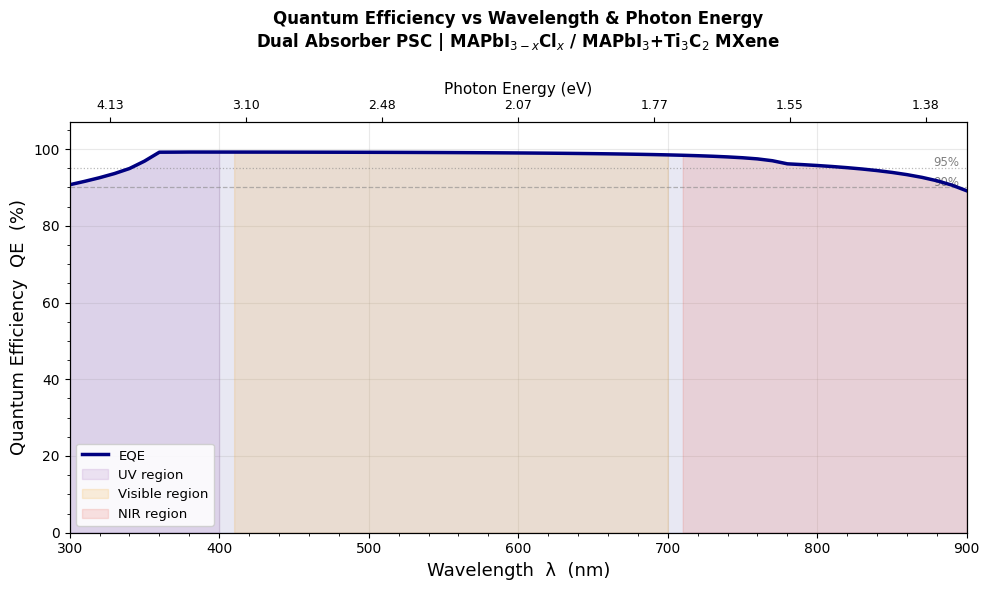

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# FIGURE 2 — Dual-axis: wavelength (nm) bottom + photon energy (eV) top
# ─────────────────────────────────────────────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(10, 6))

# main curve
ax2.plot(wl, qe, color="navy", linewidth=2.5, zorder=4, label="EQE")
ax2.fill_between(wl, qe, alpha=0.09, color="navy", zorder=1)

# colour fill by spectral region
uv_mask  = wl <= 400
vis_mask = (wl > 400) & (wl <= 700)
nir_mask = wl > 700

for region_mask, region_col, region_label in [
    (uv_mask,  "#9B59B6", "UV"),
    (vis_mask, "#F39C12", "Visible"),
    (nir_mask, "#E74C3C", "NIR"),
]:
    if region_mask.sum() > 1:
        ax2.fill_between(wl[region_mask], qe[region_mask],
                         alpha=0.15, color=region_col,
                         label=f"{region_label} region", zorder=2)

# 90% and 95% guide lines
for ref_val, ref_style in [(90, "--"), (95, ":")]:
    ax2.axhline(ref_val, color="gray", linewidth=0.9,
                linestyle=ref_style, alpha=0.55, zorder=3)
    ax2.text(wl.max() - 5, ref_val + 0.5,
             f"{ref_val}%", fontsize=8.5, color="gray", ha="right")

# top axis: photon energy (eV) — convert from wavelength
ax2_top = ax2.twiny()
wl_ticks = np.array([300, 400, 500, 600, 700, 800, 900])
ev_ticks = 1240.0 / wl_ticks
# map eV ticks to the wavelength axis position
ax2_top.set_xlim(ax2.get_xlim())
ax2_top.set_xticks(wl_ticks)
ax2_top.set_xticklabels([f"{e:.2f}" for e in ev_ticks], fontsize=9)
ax2_top.set_xlabel("Photon Energy (eV)", fontsize=11)

ax2.set_xlabel("Wavelength  λ  (nm)", fontsize=13)
ax2.set_ylabel("Quantum Efficiency  QE  (%)", fontsize=13)
ax2.set_title(
    "Quantum Efficiency vs Wavelength & Photon Energy\n"
    "Dual Absorber PSC | MAPbI$_{3-x}$Cl$_x$ / MAPbI$_3$+Ti$_3$C$_2$ MXene",
    fontsize=12, fontweight="bold", pad=25
)
ax2.set_xlim(wl.min(), wl.max())
ax2.set_ylim(0, 107)
ax2.legend(fontsize=9.5, loc="lower left", framealpha=0.88)
ax2.grid(True, alpha=0.28, zorder=0)
ax2.xaxis.set_minor_locator(ticker.AutoMinorLocator())
ax2.yaxis.set_minor_locator(ticker.AutoMinorLocator())

plt.tight_layout()
plt.savefig("QE_dual_axis.png", dpi=300, bbox_inches="tight")
print("Saved --> QE_dual_axis.png")
plt.show()

In [9]:
print("\nAll QE plots saved successfully.")
print("Files: QE_curve.png  |  QE_dual_axis.png")


All QE plots saved successfully.
Files: QE_curve.png  |  QE_dual_axis.png
